## No Bank of England Intervention Counterfactual for the 2022 LDI Crisis

This notebook asks a different question from the pre-crisis counterfactual:

**Given everything that was observed up to 27 September 2022, what path would the 10-year gilt yield have followed if the Bank of England intervention on 28 September had not occurred?**

The information set therefore **includes the crisis onset**:

- 23 September 2022: mini-budget;
- 26 September 2022: further sharp yield increase;
- 27 September 2022: yield reaches 4.4341%.

The models are then refitted using all information available through **27 September 2022** and projected forward from **28 September 2022**. No observation dated 28 September or later is fed back into the models.

This is a **fixed-origin statistical counterfactual**, not a causal estimate of the Bank of England's intervention. The difference between the observed post-intervention yield and the model-implied no-intervention path is described as a **model-based counterfactual gap**.

The five model specifications are carried over from the pre-crisis conditional-mean notebook:

1. Random Walk
2. AR(2)
3. MA(2)
4. ARMA(2,2)
5. ARIMA(2,1,2)

Keeping the same selected orders makes the pre-crisis and no-intervention exercises directly comparable.

### Import packages

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

%matplotlib inline

### Load the processed Bank of England yield data

In [2]:
DATA_PATH = Path("data") / "processed" / "boe_10y_zero_coupon_clean.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Run Notebook 01 first so that "
        "data/processed/boe_10y_zero_coupon_clean.csv is available."
    )

boe = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

required_columns = {"date", "yield_10y"}

if not required_columns.issubset(boe.columns):
    raise ValueError(
        f"Expected columns {required_columns}, but found {set(boe.columns)}"
    )

boe = (
    boe
    .sort_values("date")
    .drop_duplicates(subset="date")
    .reset_index(drop=True)
)

print(f"Loaded: {DATA_PATH}")
print(f"Observations: {len(boe)}")
print(f"Date range: {boe['date'].min().date()} to {boe['date'].max().date()}")
print(f"Missing yields: {boe['yield_10y'].isna().sum()}")

boe.head()


Loaded: data/processed/boe_10y_zero_coupon_clean.csv
Observations: 2779
Date range: 2014-01-02 to 2024-12-31
Missing yields: 0


,date,yield_10y,date_raw,yield_raw
0,2014-01-02,3.1625,02 Jan 14,3.1625
1,2014-01-03,3.1579,03 Jan 14,3.1579
2,2014-01-06,3.1053,06 Jan 14,3.1053
3,2014-01-07,3.0831,07 Jan 14,3.0831
4,2014-01-08,3.1140,08 Jan 14,3.1140


### Create modelling series

In [3]:
model_data = boe[["date", "yield_10y"]].copy()

model_data["yield_change"] = (
    model_data["yield_10y"].diff()
)

model_data["yield_change_bps"] = (
    model_data["yield_change"] * 100
)

model_data.head()

,date,yield_10y,yield_change,yield_change_bps
0,2014-01-02,3.1625,NaN,NaN
1,2014-01-03,3.1579,-0.0046,-0.46
2,2014-01-06,3.1053,-0.0526,-5.26
3,2014-01-07,3.0831,-0.0222,-2.22
4,2014-01-08,3.1140,0.0309,3.09


### Define the intervention counterfactual

The forecast origin is deliberately placed **immediately before the Bank of England intervention**.

- The final observation available to the models is **27 September 2022**.
- The first counterfactual forecast is **28 September 2022**.
- The main forecast window ends on **14 October 2022**, the end of the temporary gilt-purchase programme.

In [4]:
MINI_BUDGET = pd.Timestamp("2022-09-23")
INTERVENTION_START = pd.Timestamp("2022-09-28")
COUNTERFACTUAL_END = pd.Timestamp("2022-10-14")

# Everything known before the intervention.
pre_intervention = (
    model_data.loc[
        model_data["date"] < INTERVENTION_START
    ]
    .copy()
    .reset_index(drop=True)
)

# Actual observations after the intervention begins.
intervention_window = (
    model_data.loc[
        (model_data["date"] >= INTERVENTION_START)
        & (model_data["date"] <= COUNTERFACTUAL_END)
    ]
    .copy()
    .reset_index(drop=True)
)

if pre_intervention.empty:
    raise ValueError("No observations are available before the intervention.")

if intervention_window.empty:
    raise ValueError("No observations are available in the intervention window.")

LAST_INFO_DATE = pre_intervention["date"].max()
LAST_INFO_YIELD = float(pre_intervention["yield_10y"].iloc[-1])
CF_HORIZON = len(intervention_window)

print(f"Last information date: {LAST_INFO_DATE.date()}")
print(f"Last observed yield before intervention: {LAST_INFO_YIELD:.4f}%")
print(f"Counterfactual start: {intervention_window['date'].min().date()}")
print(f"Counterfactual end: {intervention_window['date'].max().date()}")
print(f"Forecast horizon: {CF_HORIZON} market observations")

assert LAST_INFO_DATE < INTERVENTION_START
assert intervention_window["date"].min() >= INTERVENTION_START

Last information date: 2022-09-27
Last observed yield before intervention: 4.4341%
Counterfactual start: 2022-09-28
Counterfactual end: 2022-10-14
Forecast horizon: 13 market observations


### Inspect the observations immediately before intervention

In [5]:
event_context = model_data.loc[
    model_data["date"].between(
        pd.Timestamp("2022-09-20"),
        pd.Timestamp("2022-10-04")
    ),
    ["date", "yield_10y", "yield_change_bps"]
].copy()

display(event_context)

,date,yield_10y,yield_change_bps
2202,2022-09-20,3.3364,13.08
2203,2022-09-21,3.3695,3.31
2204,2022-09-22,3.5516,18.21
2205,2022-09-23,3.8426,29.10
2206,2022-09-26,4.1817,33.91
2207,2022-09-27,4.4341,25.24
2208,2022-09-28,4.0517,-38.24
2209,2022-09-29,4.1210,6.93
2210,2022-09-30,4.1021,-1.89
2211,2022-10-03,3.9766,-12.55


### Fixed model specifications

In [6]:
BEST_AR_P = 2
BEST_MA_Q = 2
BEST_ARMA_P = 2
BEST_ARMA_Q = 2
BEST_ARIMA_ORDER = (2, 1, 2)

model_specifications = pd.DataFrame({
    "family": [
        "Random Walk",
        "AR",
        "MA",
        "ARMA",
        "ARIMA"
    ],
    "specification": [
        "Random Walk",
        f"AR({BEST_AR_P})",
        f"MA({BEST_MA_Q})",
        f"ARMA({BEST_ARMA_P},{BEST_ARMA_Q})",
        f"ARIMA{BEST_ARIMA_ORDER}"
    ]
})

model_specifications

,family,specification
0,Random Walk,Random Walk
1,AR,AR(2)
2,MA,MA(2)
3,ARMA,"ARMA(2,2)"
4,ARIMA,"ARIMA(2, 1, 2)"


### Helper functions

In [7]:
def fit_sarimax(
    endog,
    order,
    trend="n"
):
    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            ConvergenceWarning
        )

        model = SARIMAX(
            endog,
            order=order,
            trend=trend,
            simple_differencing=False,
            enforce_stationarity=True,
            enforce_invertibility=True
        )

        fit = model.fit(disp=False)

    return fit


def forecast_changes_to_level(
    fit,
    last_level,
    horizon
):
    forecast_change_bps = np.asarray(
        fit.get_forecast(
            steps=horizon
        ).predicted_mean,
        dtype=float
    )

    forecast_level = (
        last_level
        + np.cumsum(
            forecast_change_bps
        ) / 100
    )

    return forecast_level


def clean_column_name(name):
    return (
        name
        .lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace(",", "_")
    )

### Refit all five models using information through 27 September

This is the crucial counterfactual step.

The model history is **frozen on 27 September**. The models are then asked to forecast every observation from 28 September onward without receiving any realised post-intervention observations.

For AR, MA and ARMA, the fitted variable is the daily yield change in basis points. Forecast changes are accumulated back to the yield level.

ARIMA is estimated directly on the yield level with first differencing inside the model.

The Random Walk benchmark holds the final 27 September yield constant over the entire forecast horizon.

In [8]:
# Recompute the modelling series using only information
# that existed before intervention.

pre_intervention_level = (
    pre_intervention["yield_10y"]
    .astype(float)
    .copy()
)

pre_intervention_changes_bps = (
    pre_intervention_level
    .diff()
    .dropna()
    * 100
)

last_level = float(
    pre_intervention_level.iloc[-1]
)

horizon = len(
    intervention_window
)


# Random Walk

ni_rw = np.repeat(
    last_level,
    horizon
)


# AR(2)

ni_ar_fit = fit_sarimax(
    pre_intervention_changes_bps,
    order=(BEST_AR_P, 0, 0),
    trend="c"
)

ni_ar = forecast_changes_to_level(
    ni_ar_fit,
    last_level,
    horizon
)



# MA(2)

ni_ma_fit = fit_sarimax(
    pre_intervention_changes_bps,
    order=(0, 0, BEST_MA_Q),
    trend="c"
)

ni_ma = forecast_changes_to_level(
    ni_ma_fit,
    last_level,
    horizon
)


# ARMA(2,2)

ni_arma_fit = fit_sarimax(
    pre_intervention_changes_bps,
    order=(
        BEST_ARMA_P,
        0,
        BEST_ARMA_Q
    ),
    trend="c"
)

ni_arma = forecast_changes_to_level(
    ni_arma_fit,
    last_level,
    horizon
)


# ARIMA(2,1,2)

ni_arima_fit = fit_sarimax(
    pre_intervention_level,
    order=BEST_ARIMA_ORDER,
    trend="n"
)

ni_arima = np.asarray(
    ni_arima_fit
    .get_forecast(
        steps=horizon
    )
    .predicted_mean,
    dtype=float
)


no_intervention_forecasts = {
    "Random Walk": ni_rw,
    f"AR({BEST_AR_P})": ni_ar,
    f"MA({BEST_MA_Q})": ni_ma,
    f"ARMA({BEST_ARMA_P},{BEST_ARMA_Q})": ni_arma,
    f"ARIMA{BEST_ARIMA_ORDER}": ni_arima,
}

print(
    "Generated fixed-origin no-intervention forecasts "
    f"for {horizon} market observations."
)

Generated fixed-origin no-intervention forecasts for 13 market observations.


### Counterfactual forecast table

The table compares the actual observed yield after intervention with the five paths predicted from the information set frozen on 27 September.

In [9]:
no_intervention_table = intervention_window[
    ["date", "yield_10y"]
].copy()

no_intervention_table = (
    no_intervention_table
    .rename(
        columns={
            "yield_10y": "Actual Yield (%)"
        }
    )
)

for name, forecast in no_intervention_forecasts.items():
    no_intervention_table[name] = np.asarray(
        forecast,
        dtype=float
    )

no_intervention_table.round(4)


/var/folders/zd/03r02b8n5l7gc6xlngchm6vc0000gp/T/ipykernel_80355/553573908.py:20: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  no_intervention_table.round(4)


,date,Actual Yield (%),Random Walk,AR(2),MA(2),"ARMA(2,2)","ARIMA(2, 1, 2)"
0,2022-09-28,4.0517,4.4341,4.4400,4.4394,4.4559,4.4497
1,2022-09-29,4.1210,4.4341,4.4418,4.4408,4.4765,4.4606
2,2022-09-30,4.1021,4.4341,4.4424,4.4414,4.4982,4.4668
3,2022-10-03,3.9766,4.4341,4.4430,4.4420,4.5189,4.4706
4,2022-10-04,3.9036,4.4341,4.4436,4.4426,4.5405,4.4728
5,2022-10-05,4.0527,4.4341,4.4442,4.4431,4.5612,4.4741
6,2022-10-06,4.2134,4.4341,4.4447,4.4437,4.5828,4.4749
7,2022-10-07,4.2826,4.4341,4.4453,4.4443,4.6035,4.4754
8,2022-10-10,4.5445,4.4341,4.4459,4.4449,4.6250,4.4757
9,2022-10-11,4.4839,4.4341,4.4465,4.4454,4.6457,4.4758


#### Focus on the first week after intervention

In [10]:
early_comparison = (
    no_intervention_table.loc[
        no_intervention_table["date"] <= pd.Timestamp("2022-10-04")
    ]
    .copy()
    .reset_index(drop=True)
)

early_comparison.round(4)

/var/folders/zd/03r02b8n5l7gc6xlngchm6vc0000gp/T/ipykernel_80355/4344865.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  early_comparison.round(4)


,date,Actual Yield (%),Random Walk,AR(2),MA(2),"ARMA(2,2)","ARIMA(2, 1, 2)"
0,2022-09-28,4.0517,4.4341,4.4400,4.4394,4.4559,4.4497
1,2022-09-29,4.1210,4.4341,4.4418,4.4408,4.4765,4.4606
2,2022-09-30,4.1021,4.4341,4.4424,4.4414,4.4982,4.4668
3,2022-10-03,3.9766,4.4341,4.4430,4.4420,4.5189,4.4706
4,2022-10-04,3.9036,4.4341,4.4436,4.4426,4.5405,4.4728


#### Counterfactual Results

Using information available up to 27 September 2022, all five models forecast the 10-year gilt yield to remain around 4.43–4.46% on 28 September. The actual yield was 4.0517%, around 38–40 basis points below the model forecasts. Over the following days, the models begin to diverge, with ARMA(2,2) producing the strongest upward path while the Random Walk, AR(2), MA(2), and ARIMA(2,1,2) remain more stable. This increasing spread shows that the longer-horizon counterfactual becomes more model-dependent. These differences should be interpreted as model-based counterfactual gaps rather than causal estimates of the Bank of England intervention.

### Combined no-intervention counterfactual plot

The observed line contains the realised post-intervention data. The dashed lines are forecasts that never receive those observations.

A counterfactual path above the observed yield means that the realised yield was lower than the continuation predicted by that model. This is a **counterfactual gap**, not by itself proof that the intervention caused the full difference.

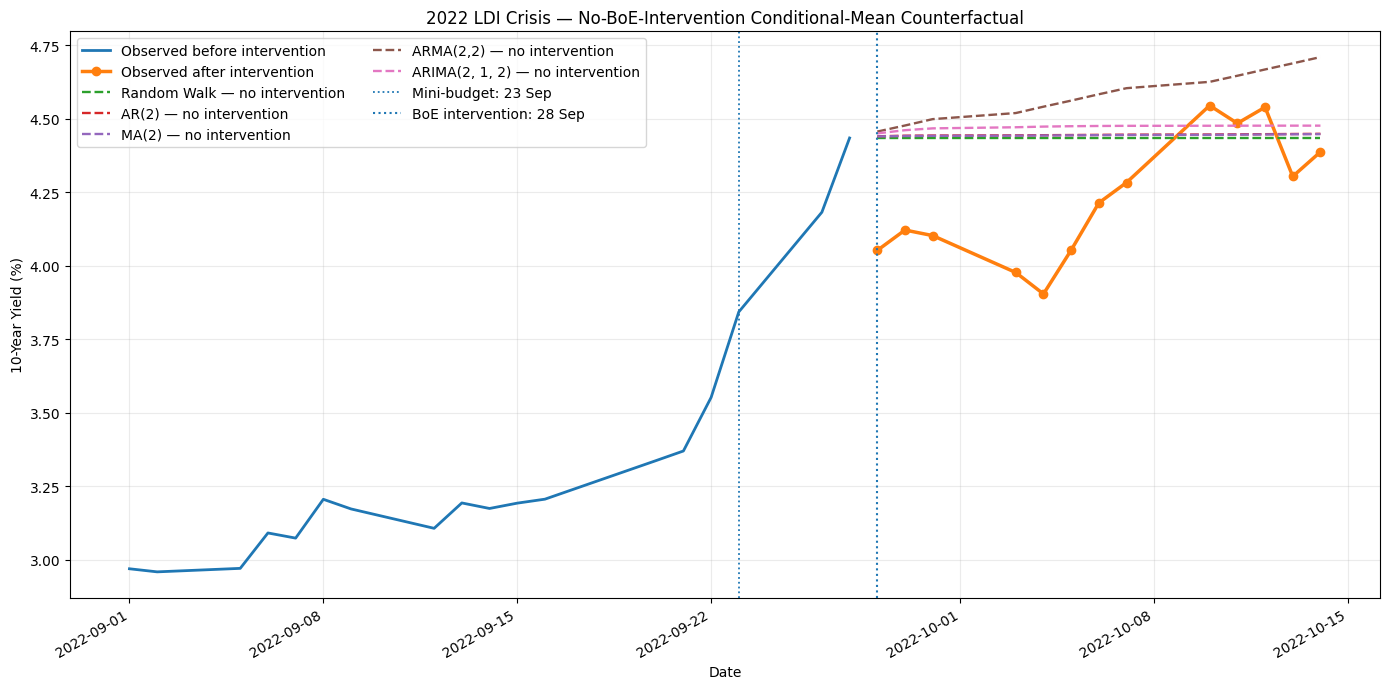

In [11]:
fig, ax = plt.subplots(
    figsize=(14, 7)
)

# Context before intervention
context = model_data.loc[
    (model_data["date"] >= pd.Timestamp("2022-09-01"))
    & (model_data["date"] < INTERVENTION_START)
]

ax.plot(
    context["date"],
    context["yield_10y"],
    linewidth=2,
    label="Observed before intervention"
)

# Actual post-intervention path
ax.plot(
    intervention_window["date"],
    intervention_window["yield_10y"],
    linewidth=2.5,
    marker="o",
    label="Observed after intervention"
)

# Five fixed-origin no-intervention paths
for name, forecast in no_intervention_forecasts.items():
    ax.plot(
        intervention_window["date"],
        forecast,
        linestyle="--",
        linewidth=1.7,
        label=f"{name} — no intervention"
    )

ax.axvline(
    MINI_BUDGET,
    linestyle=":",
    linewidth=1.3,
    label="Mini-budget: 23 Sep"
)

ax.axvline(
    INTERVENTION_START,
    linestyle=":",
    linewidth=1.5,
    label="BoE intervention: 28 Sep"
)

ax.set_title(
    "2022 LDI Crisis — No-BoE-Intervention Conditional-Mean Counterfactual"
)

ax.set_xlabel("Date")
ax.set_ylabel("10-Year Yield (%)")

ax.grid(alpha=0.25)
ax.legend(ncol=2)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Full comparison plus zoomed model forecasts

The top panel preserves the scale of the actual crisis-period yield. The bottom panel zooms into the five model paths so that small differences between model specifications remain visible.

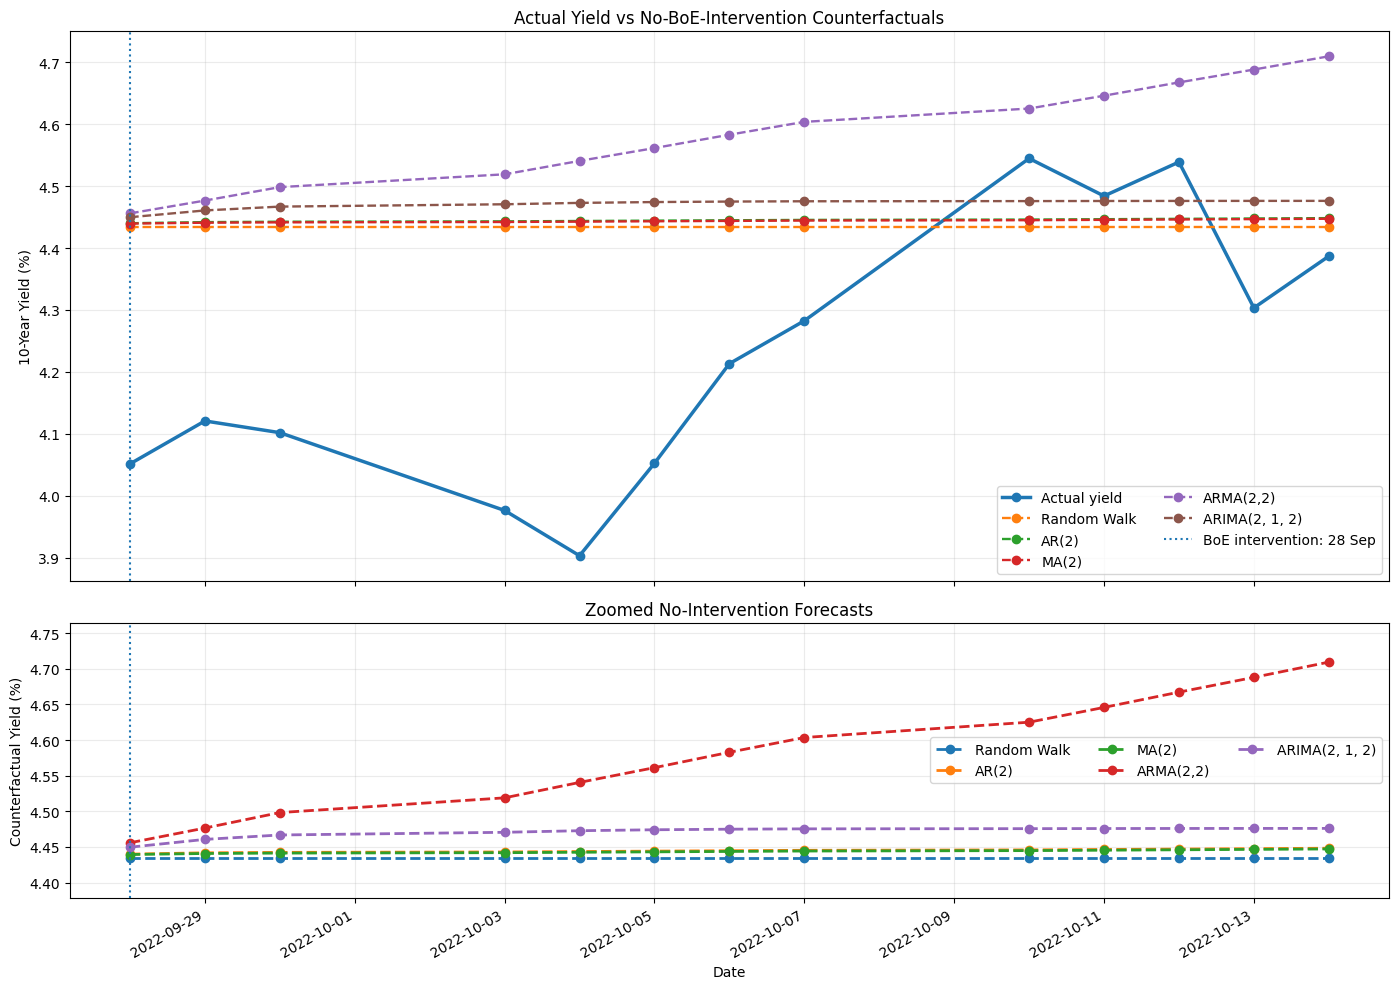

In [12]:
model_columns = list(
    no_intervention_forecasts.keys()
)

plot_table = no_intervention_table.copy()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1]
    }
)


# ------------------------------------------------------------
# Top: actual yield and all counterfactuals
# ------------------------------------------------------------

ax = axes[0]

ax.plot(
    plot_table["date"],
    plot_table["Actual Yield (%)"],
    marker="o",
    linewidth=2.5,
    label="Actual yield"
)

for model in model_columns:
    ax.plot(
        plot_table["date"],
        plot_table[model],
        marker="o",
        linestyle="--",
        linewidth=1.7,
        label=model
    )

ax.axvline(
    INTERVENTION_START,
    linestyle=":",
    linewidth=1.5,
    label="BoE intervention: 28 Sep"
)

ax.set_ylabel("10-Year Yield (%)")
ax.set_title(
    "Actual Yield vs No-BoE-Intervention Counterfactuals"
)
ax.grid(alpha=0.25)
ax.legend(ncol=2)


# ------------------------------------------------------------
# Bottom: zoomed counterfactual paths
# ------------------------------------------------------------

ax = axes[1]

for model in model_columns:
    ax.plot(
        plot_table["date"],
        plot_table[model],
        marker="o",
        linestyle="--",
        linewidth=2,
        label=model
    )

forecast_min = (
    plot_table[model_columns]
    .to_numpy()
    .min()
)

forecast_max = (
    plot_table[model_columns]
    .to_numpy()
    .max()
)

padding = max(
    0.02,
    (forecast_max - forecast_min) * 0.20
)

ax.set_ylim(
    forecast_min - padding,
    forecast_max + padding
)

ax.axvline(
    INTERVENTION_START,
    linestyle=":",
    linewidth=1.5
)

ax.set_ylabel("Counterfactual Yield (%)")
ax.set_xlabel("Date")
ax.set_title(
    "Zoomed No-Intervention Forecasts"
)
ax.grid(alpha=0.25)
ax.legend(ncol=3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Plot each model against the realised post-intervention yield

These panels make the comparison with each individual specification easier to read.

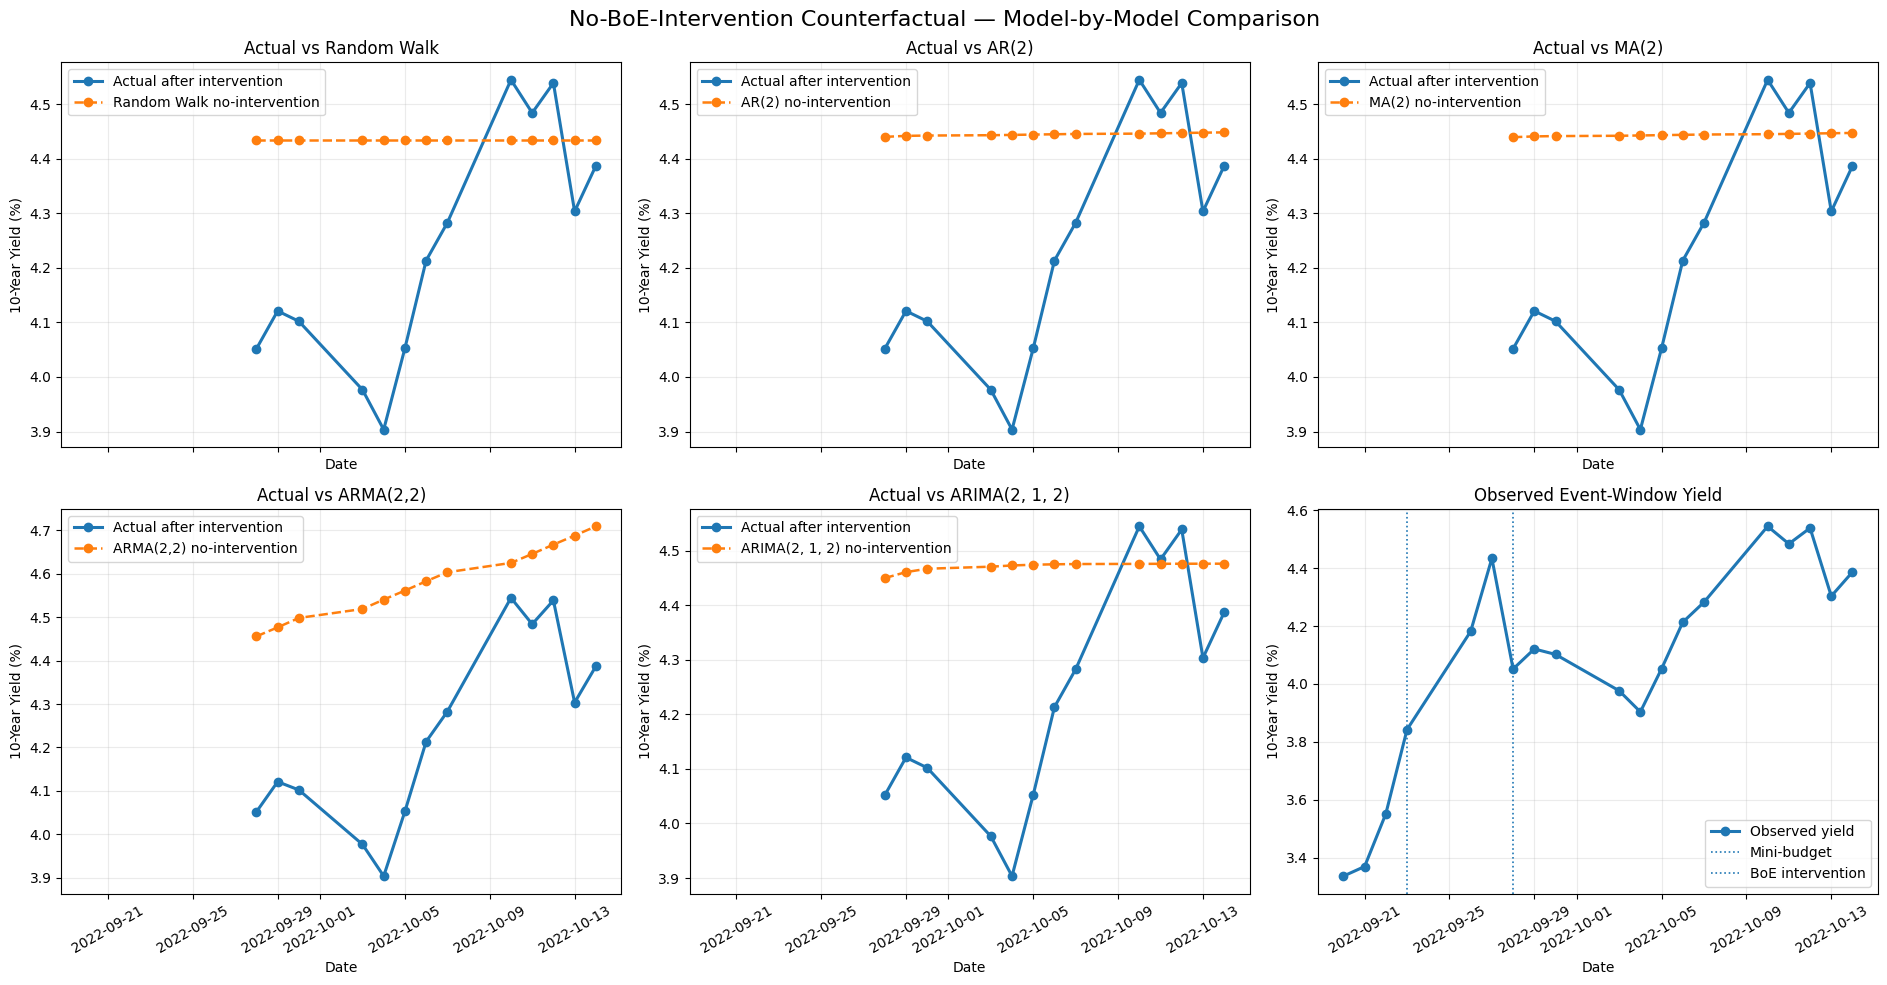

In [13]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(19, 10),
    sharex=True
)

axes = axes.flatten()

for ax, (name, forecast) in zip(
    axes[:5],
    no_intervention_forecasts.items()
):
    ax.plot(
        intervention_window["date"],
        intervention_window["yield_10y"],
        marker="o",
        linewidth=2.2,
        label="Actual after intervention"
    )

    ax.plot(
        intervention_window["date"],
        forecast,
        marker="o",
        linestyle="--",
        linewidth=1.8,
        label=f"{name} no-intervention"
    )

    ax.set_title(
        f"Actual vs {name}"
    )

    ax.set_xlabel("Date")
    ax.set_ylabel("10-Year Yield (%)")
    ax.grid(alpha=0.25)
    ax.legend()
    ax.tick_params(
        axis="x",
        rotation=30
    )

# Sixth panel: actual event path only
ax = axes[5]

event_plot = model_data.loc[
    model_data["date"].between(
        pd.Timestamp("2022-09-20"),
        COUNTERFACTUAL_END
    )
]

ax.plot(
    event_plot["date"],
    event_plot["yield_10y"],
    marker="o",
    linewidth=2.2,
    label="Observed yield"
)

ax.axvline(
    MINI_BUDGET,
    linestyle=":",
    linewidth=1.2,
    label="Mini-budget"
)

ax.axvline(
    INTERVENTION_START,
    linestyle=":",
    linewidth=1.2,
    label="BoE intervention"
)

ax.set_title(
    "Observed Event-Window Yield"
)
ax.set_xlabel("Date")
ax.set_ylabel("10-Year Yield (%)")
ax.grid(alpha=0.25)
ax.legend()
ax.tick_params(
    axis="x",
    rotation=30
)

plt.suptitle(
    "No-BoE-Intervention Counterfactual — Model-by-Model Comparison",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Calculate the model-based counterfactual gaps

For each model,

$$
\text{gap}_{t}^{(m)} = 100\left(y_t^{actual}-
\hat y_t^{no\ intervention,m}
\right)
$$

in basis points.

Interpretation:

- **negative gap:** the actual observed yield is below the model-implied no-intervention path;
- **positive gap:** the actual observed yield is above the model-implied no-intervention path.

These are descriptive model-based gaps. They should not be presented as identified causal treatment effects.

In [14]:
gap_table = no_intervention_table[
    ["date", "Actual Yield (%)"]
].copy()

for model in model_columns:
    gap_table[f"{model} gap (bps)"] = (
        (
            no_intervention_table["Actual Yield (%)"]
            - no_intervention_table[model]
        )
        * 100
    )

gap_table.round(2)

/var/folders/zd/03r02b8n5l7gc6xlngchm6vc0000gp/T/ipykernel_80355/3279111162.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  gap_table.round(2)


,date,Actual Yield (%),Random Walk gap (bps),AR(2) gap (bps),MA(2) gap (bps),"ARMA(2,2) gap (bps)","ARIMA(2, 1, 2) gap (bps)"
0,2022-09-28,4.05,-38.24,-38.83,-38.77,-40.42,-39.80
1,2022-09-29,4.12,-31.31,-32.08,-31.98,-35.55,-33.96
2,2022-09-30,4.10,-33.20,-34.03,-33.93,-39.61,-36.47
3,2022-10-03,3.98,-45.75,-46.64,-46.54,-54.23,-49.40
4,2022-10-04,3.90,-53.05,-54.00,-53.90,-63.69,-56.92
5,2022-10-05,4.05,-38.14,-39.15,-39.04,-50.85,-42.14
6,2022-10-06,4.21,-22.07,-23.13,-23.03,-36.94,-26.15
7,2022-10-07,4.28,-15.15,-16.27,-16.17,-32.09,-19.28
8,2022-10-10,4.54,11.04,9.86,9.96,-8.05,6.88
9,2022-10-11,4.48,4.98,3.74,3.85,-16.18,0.81


### Summary of the counterfactual gaps


In [15]:
gap_summary_rows = []

for model in model_columns:
    gap = (
        (
            no_intervention_table["Actual Yield (%)"]
            - no_intervention_table[model]
        )
        * 100
    )

    gap_summary_rows.append({
        "model": model,
        "mean_gap_bps": gap.mean(),
        "median_gap_bps": gap.median(),
        "minimum_gap_bps": gap.min(),
        "maximum_gap_bps": gap.max(),
        "final_gap_bps": gap.iloc[-1]
    })

gap_summary = (
    pd.DataFrame(gap_summary_rows)
    .sort_values("mean_gap_bps")
    .reset_index(drop=True)
)

gap_summary.round(2)

,model,mean_gap_bps,median_gap_bps,minimum_gap_bps,maximum_gap_bps,final_gap_bps
0,"ARMA(2,2)",-35.47,-36.94,-63.69,-8.05,-32.25
1,"ARIMA(2, 1, 2)",-24.33,-26.15,-56.92,6.88,-8.92
2,AR(2),-21.69,-23.13,-54.00,9.86,-6.14
3,MA(2),-21.59,-23.03,-53.90,9.96,-6.04
4,Random Walk,-20.63,-22.07,-53.05,11.04,-4.73


### Cross-model counterfactual range

In [16]:
forecast_matrix = (
    no_intervention_table[
        model_columns
    ]
)

counterfactual_range = pd.DataFrame({
    "date": no_intervention_table["date"],
    "Actual Yield (%)": no_intervention_table["Actual Yield (%)"],
    "Lowest model forecast (%)": forecast_matrix.min(axis=1),
    "Median model forecast (%)": forecast_matrix.median(axis=1),
    "Highest model forecast (%)": forecast_matrix.max(axis=1)
})

counterfactual_range["Actual minus median (bps)"] = (
    (
        counterfactual_range["Actual Yield (%)"]
        - counterfactual_range["Median model forecast (%)"]
    )
    * 100
)

counterfactual_range.round(4)

/var/folders/zd/03r02b8n5l7gc6xlngchm6vc0000gp/T/ipykernel_80355/2299885648.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  counterfactual_range.round(4)


,date,Actual Yield (%),Lowest model forecast (%),Median model forecast (%),Highest model forecast (%),Actual minus median (bps)
0,2022-09-28,4.0517,4.4341,4.4400,4.4559,-38.8272
1,2022-09-29,4.1210,4.4341,4.4418,4.4765,-32.0791
2,2022-09-30,4.1021,4.4341,4.4424,4.4982,-34.0315
3,2022-10-03,3.9766,4.4341,4.4430,4.5189,-46.6403
4,2022-10-04,3.9036,4.4341,4.4436,4.5405,-53.9984
5,2022-10-05,4.0527,4.4341,4.4442,4.5612,-39.1466
6,2022-10-06,4.2134,4.4341,4.4447,4.5828,-23.1347
7,2022-10-07,4.2826,4.4341,4.4453,4.6035,-16.2729
8,2022-10-10,4.5445,4.4341,4.4459,4.6250,9.8590
9,2022-10-11,4.4839,4.4341,4.4465,4.6457,3.7409


### Interpretation

This exercise should be interpreted separately from the earlier no-crisis counterfactual.

The **no-crisis counterfactual** freezes the information set on 22 September 2022, before the mini-budget. It asks what yields might have looked like if the pre-crisis conditional-mean dynamics had continued.

The **no-BoE-intervention counterfactual** freezes the information set on 27 September 2022. It therefore allows the models to observe the large yield increases on 23, 26 and 27 September before projecting forward from 28 September.

This makes the second counterfactual specifically useful for asking whether the realised post-28-September yield path was lower or higher than would have been expected if the crisis dynamics observed before intervention had simply continued.

A negative model-based gap after 28 September means that the observed yield lies below that model's no-intervention forecast. It is consistent with the intervention period being associated with lower yields than the statistical continuation predicted by that model, but it is **not sufficient to attribute the full difference causally to the Bank of England intervention**. Other information and market developments occurring after 27 September are not separately identified by these univariate models.

### Save outputs

In [17]:
OUTPUT_DIR = (
    Path("outputs")
    / "conditional_mean_no_boe_intervention"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

no_intervention_table.to_csv(
    OUTPUT_DIR
    / "no_boe_intervention_counterfactual_forecasts.csv",
    index=False
)

early_comparison.to_csv(
    OUTPUT_DIR
    / "no_boe_early_window_comparison.csv",
    index=False
)

gap_table.to_csv(
    OUTPUT_DIR
    / "no_boe_counterfactual_gaps_bps.csv",
    index=False
)

gap_summary.to_csv(
    OUTPUT_DIR
    / "no_boe_counterfactual_gap_summary.csv",
    index=False
)

counterfactual_range.to_csv(
    OUTPUT_DIR
    / "no_boe_counterfactual_cross_model_range.csv",
    index=False
)

print(
    "Saved no-intervention conditional-mean outputs to:"
)
print(
    OUTPUT_DIR.resolve()
)


Saved no-intervention conditional-mean outputs to:
/Users/qp252008/Downloads/Dissertation/outputs/conditional_mean_no_boe_intervention
